In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.stats.multitest import multipletests

In [2]:
df = pd.read_csv("/scratch1/smaruj/CTCF_elimination/gamma_300.0/successful_optimizations.tsv", sep="\t")

In [3]:
len(df)

216

In [4]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [5]:
df = df[df['URQ_diff'] < 0.0]

In [6]:
len(df)

216

In [7]:
flank = (100000 - 2048) // 2

In [8]:
from scipy.stats import pearsonr, wilcoxon

In [9]:
mean_diffs_f = []
max_diffs_f = []

mean_diffs_r = []
max_diffs_r = []

max_before = []
max_after = []

mean_signed_diffs_f = []
max_signed_diffs_f = []

mean_signed_diffs_r = []
max_signed_diffs_r = []

correlations_f = []
all_diffs_f = []  # store per-sequence difference vectors
pvals_f = []

correlations_r = []
all_diffs_r = []  # store per-sequence difference vectors
pvals_r = []

for i, row in df.iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    
    orig = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/original_puffinD_preds/{chrom}_{centered_start}_{centered_end}_original.npy")
    orig_gro_cap_forward = orig[0, 4, flank:-flank]
    orig_gro_cap_reverse = orig[0, 5, flank:-flank]
    
    max_before.append(max(np.max(orig_gro_cap_forward), np.max(orig_gro_cap_reverse)))
    
    opt = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/optimized_puffinD_preds/{chrom}_{centered_start}_{centered_end}_optimized.npy")
    opt_gro_cap_forward = opt[0, 4, flank:-flank]
    opt_gro_cap_reverse = opt[0, 5, flank:-flank]
    
    max_after.append(max(np.max(opt_gro_cap_forward), np.max(opt_gro_cap_reverse)))
    
    diff_f = opt_gro_cap_forward - orig_gro_cap_forward
    all_diffs_f.append(diff_f)
    
    diff_r = opt_gro_cap_reverse - orig_gro_cap_reverse
    all_diffs_r.append(diff_r)
    
    # direction-aware stats
    mean_signed_diffs_f.append(np.mean(diff_f))
    mean_signed_diffs_r.append(np.mean(diff_r))
    max_signed_diffs_f.append(np.max(diff_f))
    max_signed_diffs_r.append(np.max(diff_r))
    
    mean_diffs_f.append(np.mean(np.abs(diff_f)))
    max_diffs_f.append(np.max(np.abs(diff_f)))
    correlations_f.append(pearsonr(orig_gro_cap_forward, opt_gro_cap_forward)[0])
    
    # Wilcoxon test across all positions in the sequence
    stat_f, pval_f = wilcoxon(orig_gro_cap_forward, opt_gro_cap_forward)
    pvals_f.append(pval_f)
    
    mean_diffs_r.append(np.mean(np.abs(diff_r)))
    max_diffs_r.append(np.max(np.abs(diff_r)))
    correlations_r.append(pearsonr(orig_gro_cap_reverse, opt_gro_cap_reverse)[0])
    
    # Wilcoxon test across all positions in the sequence
    stat_r, pval_r = wilcoxon(orig_gro_cap_reverse, opt_gro_cap_reverse)
    pvals_r.append(pval_r)

In [10]:
df["max_before"] = max_before
df["max_after"] = max_after

In [11]:
df["max_diff"] = df["max_after"] - df["max_before"]

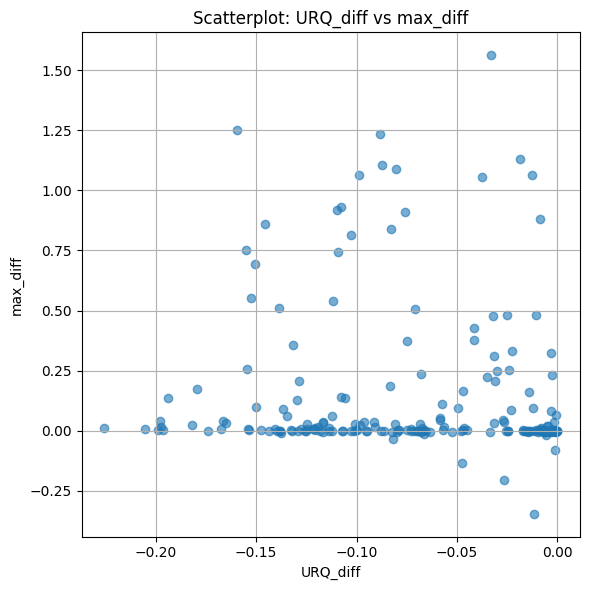

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(df["URQ_diff"], df["max_diff"], alpha=0.6)

plt.xlabel("URQ_diff")
plt.ylabel("max_diff")
plt.title("Scatterplot: URQ_diff vs max_diff")

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df["mean_signed_diff"] = mean_signed_diffs
df["max_signed_diff"]   = max_signed_diffs

df["max_before"] = max_before
df["max_after"] = max_after

df["mean_abs_diff"]     = mean_diffs
df["max_abs_diff"]      = max_diffs
df["correlation"]       = correlations
df["pval"]              = pvals

In [ ]:
from statsmodels.stats.multitest import multipletests

# FDR correction
reject, pvals_corrected, _, _ = multipletests(pvals, method="fdr_bh")

df["pval_raw"]       = pvals
df["pval_corrected"] = pvals_corrected
df["reject_null"]    = reject  # True if significant after correction

In [ ]:
sum(reject)

In [ ]:
def classify_change(mean_diff, reject):
    if not reject:
        return "no_change"
    elif mean_diff >= 0:
        return "increased"
    else:  # mean_diff <= 0
        return "decreased"

df["change_category"] = [
    classify_change(m, r) for m, r in zip(df["mean_signed_diff"], df["reject_null"])
]

In [13]:
import seaborn as sns

In [ ]:
# Count categories
counts = df["change_category"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette=["#4daf4a","#e41a1c","#999999"])
plt.ylabel("Number of sequences")
plt.xlabel("Change category")
plt.title("Significant changes in predicted signal (FDR < 0.05)")
plt.tight_layout()
plt.show()

In [ ]:
categories = counts.index
values = counts.values
bottom = 0
colors = ["#4daf4a", "#e41a1c", "#999999"]

plt.figure(figsize=(1.5, 6))
for val, cat, color in zip(values, categories, colors):
    plt.bar("All sequences", val, bottom=bottom, color=color, label=cat)
    bottom += val

plt.ylabel("Number of sequences")
# plt.title("Significant changes in predicted signal (FDR < 0.05)")

# Move legend to the right of the plot
plt.legend(title="Change category", bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu

In [ ]:
df.columns

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x="change_category", y="URQ_result", data=df, palette=["#4daf4a","#e41a1c","#999999"])
plt.ylabel("URQ_result")
plt.xlabel("Change category")
plt.title("URQ_result by Change Category")
plt.tight_layout()
plt.show()

In [ ]:
# Statistical test: compare 'increase' vs 'decrease'
increase_vals = df[df["change_category"] == "increased"]["URQ_result"]
decrease_vals = df[df["change_category"] == "decreased"]["URQ_result"]
nochange_vals = df[df["change_category"] == "no_change"]["URQ_result"]

# Mann-Whitney U test (non-parametric)
stat_dec, p_dec = mannwhitneyu(decrease_vals, increase_vals, alternative='greater')
stat_no, p_no = mannwhitneyu(nochange_vals, increase_vals, alternative='greater')

print(f"Decrease vs Increase: U={stat_dec}, p={p_dec:.3e}")
print(f"No change vs Increase: U={stat_no}, p={p_no:.3e}")

In [ ]:
print("number of optimizations with increase", len(increase_vals))
print("number of optimizations with decrease", len(decrease_vals))
print("number of optimizations with no change", len(nochange_vals))

In [ ]:
df.columns

In [ ]:
chromatin_cols = ["active_fraction", "neutral_fraction", "repressive_fraction"]

for col in chromatin_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="change_category", y=col, data=df, palette=["#4daf4a","#e41a1c","#999999"])
    plt.ylabel(col)
    plt.xlabel("Change category")
    plt.title(f"{col} by Change Category")
    plt.tight_layout()
    plt.show()

In [ ]:
for col in chromatin_cols:
    print(f"\n--- {col} ---")
    increase_vals = df[df["change_category"] == "increased"][col]
    decrease_vals = df[df["change_category"] == "decreased"][col]
    nochange_vals = df[df["change_category"] == "no_change"][col]
    
    stat_dec, p_dec = mannwhitneyu(decrease_vals, increase_vals, alternative='two-sided')
    stat_no, p_no = mannwhitneyu(nochange_vals, increase_vals, alternative='two-sided')
    
    print(f"Decrease vs Increase: U={stat_dec}, p={p_dec:.3e}")
    print(f"No change vs Increase: U={stat_no}, p={p_no:.3e}")

In [ ]:
# Convert to array for pile-up
all_diffs = np.vstack(all_diffs)  # shape: (n_sequences, 2048)
avg_diff = np.mean(all_diffs, axis=0)      # average difference profile
sem_diff = np.std(all_diffs, axis=0) / np.sqrt(all_diffs.shape[0])  # SEM for shading

In [ ]:
plt.figure(figsize=(14,4))

# Mean absolute differences
plt.subplot(1,3,1)
plt.hist(mean_diffs, bins=30, color="darkorange", edgecolor="black")
plt.xlabel("Mean absolute difference")
plt.ylabel("Number of sequences")
plt.title("Distribution of mean abs difference")

# Max absolute differences
plt.subplot(1,3,2)
plt.hist(max_diffs, bins=30, color="blue", edgecolor="black")
plt.xlabel("Max absolute difference")
plt.ylabel("Number of sequences")
plt.title("Distribution of max abs difference")

# Correlations
plt.subplot(1,3,3)
plt.hist(correlations, bins=30, color="green", edgecolor="black")
plt.xlabel("Pearson correlation")
plt.ylabel("Number of sequences")
plt.title("Distribution of shape correlation")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["mean_signed_diff"], bins=50, kde=True, color="steelblue")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Mean signed difference (opt - orig)")
plt.ylabel("Count")
plt.title("Distribution of mean signed differences")

plt.subplot(1,2,2)
sns.histplot(df["max_signed_diff"], bins=50, kde=True, color="darkorange")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Max signed difference (opt - orig)")
plt.ylabel("Count")
plt.title("Distribution of max signed differences")

plt.tight_layout()
plt.show()

In [ ]:
df["max_after"].describe()

In [ ]:
df["max_before"].describe()

In [14]:
tss_df = pd.read_csv("/scratch1/smaruj/puffin/tss_pro_cap_max_signal.tsv", sep="\t")

In [15]:
tss_df["max_signal"].describe()

count    51061.000000
mean         0.319779
std          0.584428
min          0.000027
25%          0.002370
50%          0.014161
75%          0.251287
max          3.944432
Name: max_signal, dtype: float64

In [16]:
from scipy.stats import mannwhitneyu

In [17]:
# Mann-Whitney U test (rank-based)
stat, pval = mannwhitneyu(df["max_after"], tss_df["max_signal"], alternative="less")
print("Mann-Whitney U p-value:", pval)

Mann-Whitney U p-value: 5.440772382041092e-06


In [18]:
# Compute percentiles of optimized values within gene distribution
percentiles = [np.mean(tss_df["max_signal"] <= x) for x in df["max_after"]]
print("Median percentile:", np.median(percentiles))

Median percentile: 0.38132821527192967


In [19]:
df["max_signed_diff"] = df["max_after"] - df["max_before"]

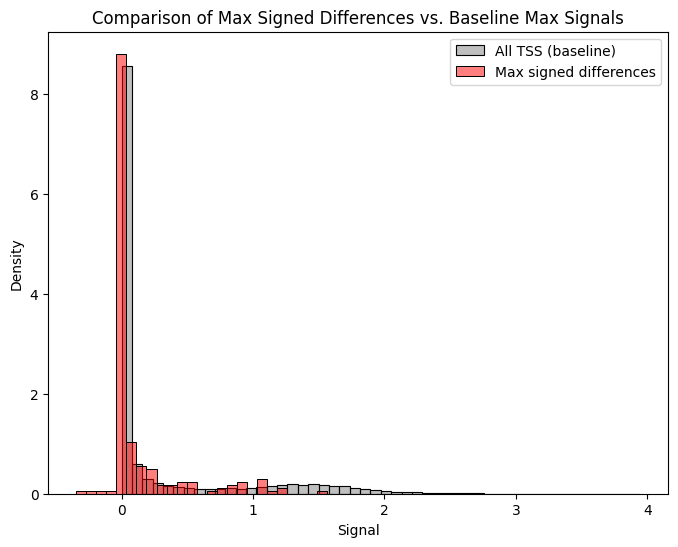

In [20]:
# Two distributions overlaid
plt.figure(figsize=(8,6))
sns.histplot(tss_df["max_signal"], color="gray", label="All TSS (baseline)", kde=False, stat="density", bins=50, alpha=0.5)
sns.histplot(df["max_signed_diff"], color="red", label="Max signed differences", kde=False, stat="density", bins=25, alpha=0.5)

plt.xlabel("Signal")
plt.ylabel("Density")
plt.legend()
plt.title("Comparison of Max Signed Differences vs. Baseline Max Signals")
plt.show()

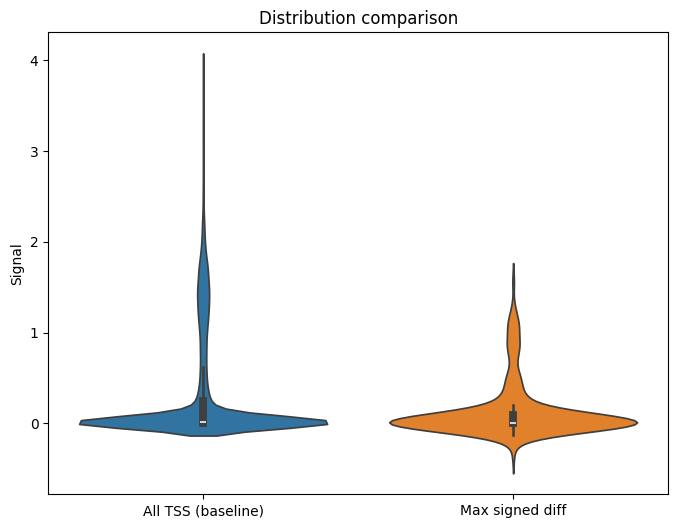

In [21]:
plt.figure(figsize=(8,6))
sns.violinplot(data=[tss_df["max_signal"], df["max_signed_diff"]], inner="box")
plt.xticks([0,1], ["All TSS (baseline)", "Max signed diff"])
plt.ylabel("Signal")
plt.title("Distribution comparison")
plt.show()

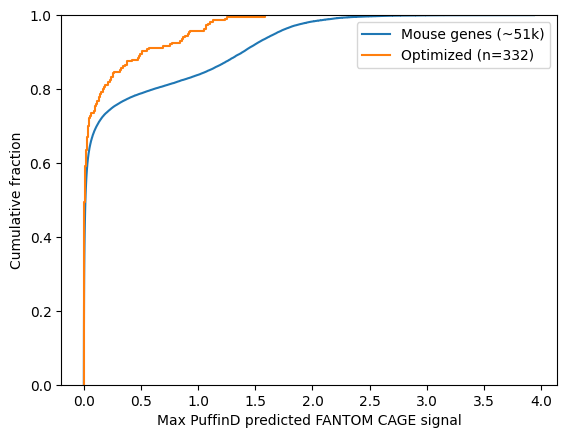

In [22]:
sns.ecdfplot(tss_df["max_signal"], label="Mouse genes (~51k)")
sns.ecdfplot(df["max_after"], label="Optimized (n=332)")
plt.xlabel("Max PuffinD predicted FANTOM CAGE signal")
plt.ylabel("Cumulative fraction")
plt.legend()
plt.show()

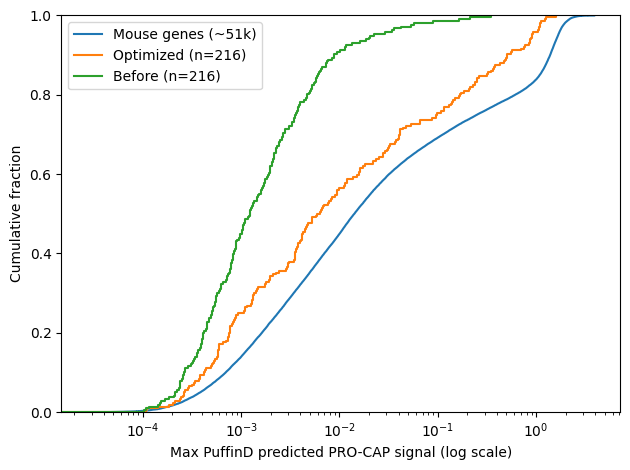

In [23]:
sns.ecdfplot(tss_df["max_signal"], label="Mouse genes (~51k)")
sns.ecdfplot(df["max_after"], label="Optimized (n=216)")
sns.ecdfplot(df["max_before"], label="Before (n=216)")

plt.xscale("log")  # log-transform x-axis
plt.xlabel("Max PuffinD predicted PRO-CAP signal (log scale)")
plt.ylabel("Cumulative fraction")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Your arrays
before = np.array(df["max_before"])       # n=311
after = np.array(df["max_after"])         # n=311
genes = np.array(tss_df["max_signal"])    # n=51000

# Convert back to raw reads
before_reads = 10**before - 1
after_reads = 10**after - 1
genes_reads = 10**genes - 1

In [25]:
before_reads.max(), after.max(), genes_reads.max()

(1.2202284, 1.5824898, 8797.978542303903)

In [26]:
# Prepare dataframe
plot_df = pd.DataFrame({
    "Reads": np.concatenate([before_reads, after_reads, genes_reads]),
    "Group": ["Before"]*len(before_reads) + ["After"]*len(after_reads) + ["Genes"]*len(genes_reads)
})

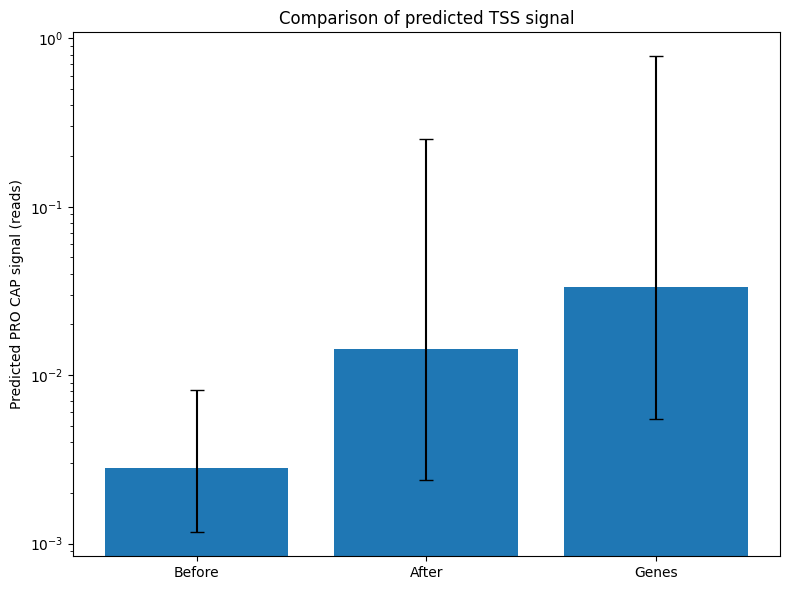

In [27]:
# Specify desired order
group_order = ["Before", "After", "Genes"]

# Compute summary statistics in the desired order
summary = plot_df.groupby("Group")["Reads"].agg(
    median="median",
    q25=lambda x: np.percentile(x, 25),
    q75=lambda x: np.percentile(x, 75)
).reindex(group_order).reset_index()

# Plot as barplot (median with IQR as error bars) in blue
plt.figure(figsize=(8,6))
plt.bar(summary["Group"], summary["median"], 
        yerr=[summary["median"] - summary["q25"], summary["q75"] - summary["median"]],
        capsize=5)

plt.yscale("log")  # log scale for better visibility
plt.ylabel("Predicted PRO CAP signal (reads)")
plt.title("Comparison of predicted TSS signal")
plt.tight_layout()

# plt.savefig("puffin_reads_barplot.svg", format='svg')

plt.show()

In [28]:
# Compute for max_before
before_values = before_reads
before_percentiles = np.percentile(before_values, [25, 50, 75])
before_mean = np.mean(before_values)
print(f"max_before: mean={before_mean:.7f}, 25th={before_percentiles[0]:.7f}, median={before_percentiles[1]:.7f}, 75th={before_percentiles[2]:.7f}")

# Compute for max_after
after_values = after_reads
after_percentiles = np.percentile(after_values, [25, 50, 75])
after_mean = np.mean(after_values)
print(f"max_after: mean={after_mean:.7f}, 25th={after_percentiles[0]:.7f}, median={after_percentiles[1]:.7f}, 75th={after_percentiles[2]:.7f}")


max_before: mean=0.0202918, 25th=0.0011634, median=0.0028070, 75th=0.0082075
max_after: mean=1.1027143, 25th=0.0023870, median=0.0142578, 75th=0.2514355


In [ ]:
# Plot pile-up
plt.figure(figsize=(12,5))
x = np.arange(len(avg_diff))
plt.plot(x, avg_diff, color="darkorange", label="Optimized - Original (mean)")
plt.fill_between(x, avg_diff - sem_diff, avg_diff + sem_diff, 
                 color="darkorange", alpha=0.3, label="± SEM")
plt.axhline(0, color="black", linestyle="--", lw=1)
plt.xlabel("Position (bp)")
plt.ylabel("Δ FANTOM CAGE prediction")
plt.title("Pile-up of signal differences across sequences")
plt.legend()
plt.tight_layout()
plt.show()

### Example plots for significant differences

In [ ]:
for i, row in df[:3].iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    
    orig = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/original_puffinD_preds/{chrom}_{centered_start}_{centered_end}_original.npy")[0, 0, flank:-flank] 
    opt  = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/optimized_puffinD_preds/{chrom}_{centered_start}_{centered_end}_optimized.npy")[0, 0, flank:-flank]
    
    plt.figure(figsize=(12, 4))
    plt.plot(orig, label="Original", color="blue")
    plt.plot(opt, label="Optimized", color="red")
    plt.title(f"Sequence {chrom}: {centered_start}-{centered_end}")
    plt.xlabel("Position")
    plt.ylabel("FANTOM CAGE prediction")
    plt.legend()
    plt.show()

# Non-significant differences examples

In [ ]:
nonsign = df[df["reject_null"] == False].reset_index(drop=True)

In [ ]:
for i, row in nonsign[:3].iterrows():
    chrom = row['chrom']
    centered_start = int(row['centered_start'])
    centered_end = int(row['centered_end'])
    
    orig = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/original_puffinD_preds/{chrom}_{centered_start}_{centered_end}_original.npy")[0, 0, flank:-flank] 
    opt  = np.load(f"/scratch1/smaruj/CTCF_elimination/gamma_300.0/optimized_puffinD_preds/{chrom}_{centered_start}_{centered_end}_optimized.npy")[0, 0, flank:-flank]
    
    plt.figure(figsize=(12, 4))
    plt.plot(orig, label="Original", color="blue")
    plt.plot(opt, label="Optimized", color="red")
    plt.title(f"Sequence {chrom}: {centered_start}-{centered_end}")
    plt.xlabel("Position")
    plt.ylabel("FANTOM CAGE prediction")
    plt.legend()
    plt.show()